In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, KBinsDiscretizer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import KernelPCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE

from sklearn.metrics import classification_report
from scipy.stats import mode

# Model
from sklearn.naive_bayes import CategoricalNB

# Metryki
from sklearn.metrics import accuracy_score

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [ ]:
# zadanie 1

def load_and_prep_titanic():
    df = pd.read_csv("Titanic Dataset.csv")
    target = 'survived'
    num_feat = ['age', 'fare']
    cat_feat = ['pclass', 'sex', 'embarked', 'sibsp', 'parch']
    feat = num_feat + cat_feat

    y = df[target]
    X = df[feat].copy()
    num_imputer = SimpleImputer(strategy='median')
    cat_imputer = SimpleImputer(strategy='most_frequent')

    X[num_feat] = num_imputer.fit_transform(X[num_feat])
    X[cat_feat] = cat_imputer.fit_transform(X[cat_feat])

    le_sex = LabelEncoder()
    X['sex'] = le_sex.fit_transform(X['sex'])

    le_embarked = LabelEncoder()
    X['embarked'] = le_embarked.fit_transform(X['embarked'])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = load_and_prep_titanic()

In [4]:
k_values = [2, 5, 10, 25]
res = []

num_feat = ['age', 'fare']
cat_feat = ['pclass', 'sex', 'embarked', 'sibsp', 'parch']

numerical_indices = [X_train.columns.get_loc(c) for c in num_feat]
categorical_indices = [X_train.columns.get_loc(c) for c in cat_feat]

# 'uniform' -> rowne czesci (np. 0-20, 20-40, 40-60, 60-80 dla 80, k = 4)
# 'quantile' -> rownoliczne czesci (w kazdym kubelku mniej wiecej ta sama liczba obserwacji)
# 'kmeans' -> klasteryzacja


for k in k_values:
    for strategy_name in ['uniform', 'quantile', 'kmeans']:
        binner = KBinsDiscretizer(n_bins=k, encode='ordinal', strategy=strategy_name,
                                  subsample=None, random_state=42)

        preprocessor = ColumnTransformer(
            transformers=[
                ('num_binner', binner, numerical_indices),
                ('cat_passthrough', 'passthrough', categorical_indices)
            ],
            remainder='drop'
        )

        model_pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', CategoricalNB())
        ])

        model_pipeline.fit(X_train, y_train)
        y_pred = model_pipeline.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)

        if strategy_name == 'uniform':
                method_name = 'Równe części (width)'
        elif strategy_name == 'quantile':
                method_name = 'Równoliczne części (quantile)'
        else:
                method_name = 'Klasteryzacja (k-means)'

        res.append({
                'k': k,
                'Metoda': method_name,
                'Accuracy': accuracy
            })

        print(f"  k={k}, Metoda: {strategy_name:<10} ... Accuracy: {accuracy:.4f}")

  k=2, Metoda: uniform    ... Accuracy: 0.7901
  k=2, Metoda: quantile   ... Accuracy: 0.7366
  k=2, Metoda: kmeans     ... Accuracy: 0.7824
  k=5, Metoda: uniform    ... Accuracy: 0.7939
  k=5, Metoda: quantile   ... Accuracy: 0.7595
  k=5, Metoda: kmeans     ... Accuracy: 0.7481
  k=10, Metoda: uniform    ... Accuracy: 0.7595
  k=10, Metoda: quantile   ... Accuracy: 0.7710
  k=10, Metoda: kmeans     ... Accuracy: 0.7519
  k=25, Metoda: uniform    ... Accuracy: 0.7634
  k=25, Metoda: quantile   ... Accuracy: 0.7595
  k=25, Metoda: kmeans     ... Accuracy: 0.7748


In [5]:
results_df = pd.DataFrame(res)

results_pivot = results_df.pivot_table(
    index='Metoda',
    columns='k',
    values='Accuracy'
)

results_pivot_formatted = results_pivot.applymap(lambda x: f"{x:.2%}" if pd.notna(x) else "Błąd")

print("\n--- Porównanie wyników klasyfikatora (Accuracy) ---")
print(results_pivot_formatted)


--- Porównanie wyników klasyfikatora (Accuracy) ---
k                                  2       5       10      25
Metoda                                                       
Klasteryzacja (k-means)        78.24%  74.81%  75.19%  77.48%
Równe części (width)           79.01%  79.39%  75.95%  76.34%
Równoliczne części (quantile)  73.66%  75.95%  77.10%  75.95%


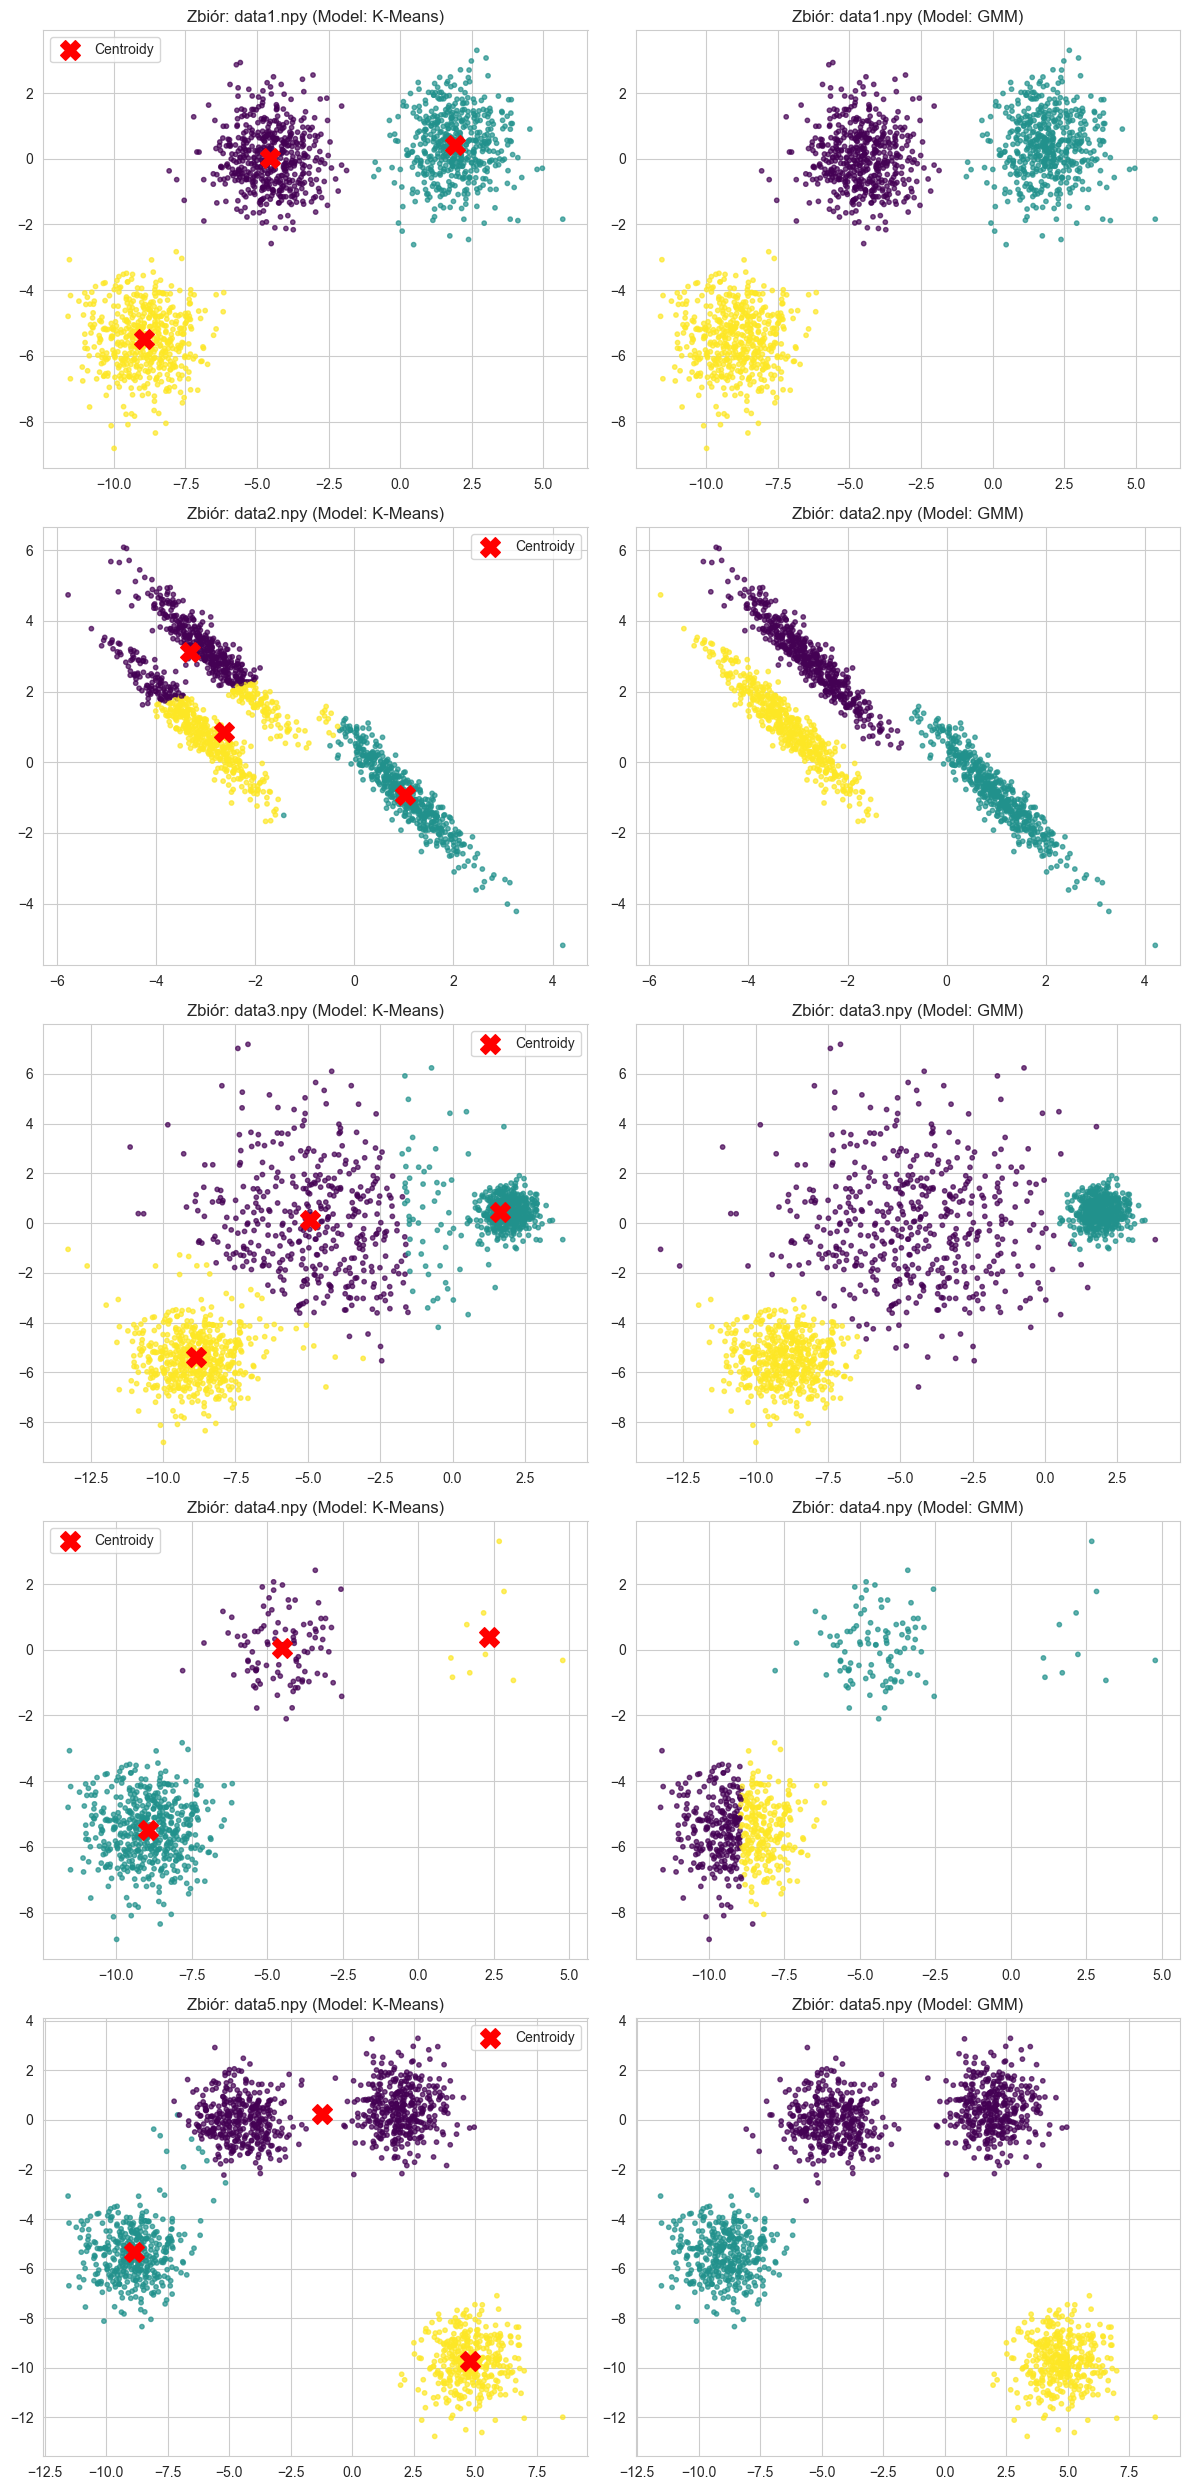

In [20]:
# zadanie 2

data_files = ['data1.npy', 'data2.npy', 'data3.npy', 'data4.npy', 'data5.npy']
k = 3

plt.figure(figsize=(12, 25))
for i, file_name in enumerate(data_files):
    data = np.load(file_name)

    # K-Means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(data)
    kmeans_labels = kmeans.predict(data)
    centroids = kmeans.cluster_centers_

    # GMM
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(data)
    gmm_labels = gmm.predict(data)

    ax1 = plt.subplot(5, 2, i * 2 + 1)
    ax1.scatter(data[:, 0], data[:, 1], c=kmeans_labels, cmap='viridis', s=10, alpha=0.7)
    ax1.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroidy')
    ax1.set_title(f"Zbiór: {file_name} (Model: K-Means)")
    ax1.legend()

    ax2 = plt.subplot(5, 2, i * 2 + 2)
    ax2.scatter(data[:, 0], data[:, 1], c=gmm_labels, cmap='viridis', s=10, alpha=0.7)
    ax2.set_title(f"Zbiór: {file_name} (Model: GMM)")

plt.tight_layout()
plt.show()

In [7]:
# zadanie 3

X_train_emb = np.load('image_emb.npy')
y_train_labels = np.load('image_labels.npy', allow_pickle=True)

X_test_emb = np.load('image_emb_test.npy')
y_test_labels = np.load('image_labels_test.npy', allow_pickle=True)


n = 10
kmeans_model = KMeans(n_clusters=n, random_state=42, n_init=10)
kmeans_model.fit(X_train_emb)

# przypisujemy label
train_cluster_ids = kmeans_model.labels_

In [8]:
labeled_indices = np.where(y_train_labels != '')[0]

# prawdziwe etykiety i przypisane ID klastrow
labeled_true_labels = y_train_labels[labeled_indices]
labeled_cluster_ids = train_cluster_ids[labeled_indices]

cluster_to_label_map = {}

for k in range(n):
    labels_in_this_cluster = labeled_true_labels[labeled_cluster_ids == k]
    if len(labels_in_this_cluster) > 0:
        most_common_label = pd.Series(labels_in_this_cluster).mode()[0]
        cluster_to_label_map[k] = most_common_label

for cluster_id, label in cluster_to_label_map.items():
    print(f"  Klaster {cluster_id} => '{label}'")

  Klaster 0 => 'deer'
  Klaster 1 => 'ship'
  Klaster 2 => 'truck'
  Klaster 3 => 'cat'
  Klaster 4 => 'frog'
  Klaster 5 => 'dog'
  Klaster 6 => 'horse'
  Klaster 7 => 'airplane'
  Klaster 8 => 'bird'
  Klaster 9 => 'automobile'


In [9]:
# ewaluacja

# predict ID klastrow dla danych testowych
test_cluster_ids = kmeans_model.predict(X_test_emb)

# translate ID klastrow na nazwy klas
test_cluster_ids_series = pd.Series(test_cluster_ids)
y_pred_labels = test_cluster_ids_series.map(cluster_to_label_map)

# y_test_labels -> prawdziwe etykiety
# y_pred_labels -> nasze predicty

accuracy = accuracy_score(y_test_labels, y_pred_labels)

print(f"Dokładność (Accuracy): {accuracy * 100:.2f} %")

print("\n--- Pełny raport klasyfikacji ---")
print(classification_report(y_test_labels, y_pred_labels))

Dokładność (Accuracy): 76.93 %

--- Pełny raport klasyfikacji ---
              precision    recall  f1-score   support

    airplane       0.97      0.54      0.69       692
  automobile       0.94      0.94      0.94       759
        bird       0.95      0.79      0.86       761
         cat       0.32      0.88      0.46       746
        deer       0.92      0.76      0.83       761
         dog       0.86      0.75      0.80       758
        frog       0.97      0.76      0.85       754
       horse       0.97      0.50      0.66       760
        ship       0.95      0.89      0.92       739
       truck       0.98      0.88      0.93       770

    accuracy                           0.77      7500
   macro avg       0.88      0.77      0.79      7500
weighted avg       0.88      0.77      0.80      7500



In [10]:
# zadanie 4

# TfidVectorizer : (tekst -> liczby)
# KernelPCA : redukcja wymiarow (lcizby -> mniej liczb)
# fetch_20_newsgroups -> zbior danych, usuwamy headery ('from', 'subject' itp.), footers, quotes itp
# pipeline : tekst -> liczby
# Tfidf buduje tabele (wiersze 11314 dokumentow, kolumny: kazde unikalne slowo)
# tf -> term frequency, im czestsze slowo tym wazniejsze
# idf -> inverse doc freq -> im bardziej rzadkie tym wazniejsze

newsgroups_train = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('pca', KernelPCA(n_components=100, kernel='rbf', random_state=42))
])
pca_matrix = pipeline.fit_transform(newsgroups_train.data)

In [11]:
print(f"Shape PCA matrix: {pca_matrix.shape}")

Shape PCA matrix: (11314, 100)


In [ ]:
# Silhouette -> mierzy jak dobrze dany punkt pasuje do swojego klastra w porownaniu do innych klastrow
# ocenia: jak blisko punkty sa od siebie wewnatrz klastra, jak daleko klastry sa od siebie nawzajem
# wynik w zakresie [-1, 1]
# -1 -> tragedia, 0 -> slabo, 1 -> idealnie
# -1 -> punkt jest prawdopodobnie w zlym klastrze
# 0  -> punkt jest na granicy dwoch klastrow
# 1  -> klaster jest gesty i daleko od innych

# Inercja -> średni błąd kwantyzacji lub sume kwadratów odleglosci.
# suma odleglosci wszystkich punktow od ich najblizszych centroidow
# w skrocie: jak ciasne sa klastry. niska ineracja = ciasne klastry (maly blad)
# gdy dodajemy wiecej klastrow to intercja zawsze maleje
# szukamy tego łokcia - punktu, w ktorym wykres sie zalamuje i zaczyna wyplaszczac

k_values_to_test = [2, 3, 4, 5, 10, 15, 18, 20, 22, 25, 30]
inertia_values = []
silhouette_values = []

np.random.seed(42)
sample_indices = np.random.choice(pca_matrix.shape[0], 2000, replace=False) # randomowe 2000 idx, bo za duzy zbior
pca_matrix_sample = pca_matrix[sample_indices]

for k in k_values_to_test:
    print(f"  Testuję k = {k}...")

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(pca_matrix)

    inertia_values.append(kmeans.inertia_)


    labels_sample = kmeans.predict(pca_matrix_sample)
    silhouette_avg = silhouette_score(pca_matrix_sample, labels_sample)
    silhouette_values.append(silhouette_avg)

    print(f"    Inercja: {kmeans.inertia_:.2f}, Silhouette (na próbce): {silhouette_avg:.4f}")

  Testuję k = 2...
    Inercja: 0.02, Silhouette (na próbce): 0.1447
  Testuję k = 3...
    Inercja: 0.02, Silhouette (na próbce): 0.1539
  Testuję k = 4...
    Inercja: 0.02, Silhouette (na próbce): 0.0689
  Testuję k = 5...
    Inercja: 0.02, Silhouette (na próbce): 0.0734
  Testuję k = 10...
    Inercja: 0.02, Silhouette (na próbce): 0.0532
  Testuję k = 15...
    Inercja: 0.02, Silhouette (na próbce): 0.0550
  Testuję k = 18...
    Inercja: 0.02, Silhouette (na próbce): 0.0501
  Testuję k = 20...
    Inercja: 0.02, Silhouette (na próbce): 0.0517
  Testuję k = 22...
    Inercja: 0.02, Silhouette (na próbce): 0.0485
  Testuję k = 25...
    Inercja: 0.02, Silhouette (na próbce): 0.0500
  Testuję k = 30...
    Inercja: 0.02, Silhouette (na próbce): 0.0544


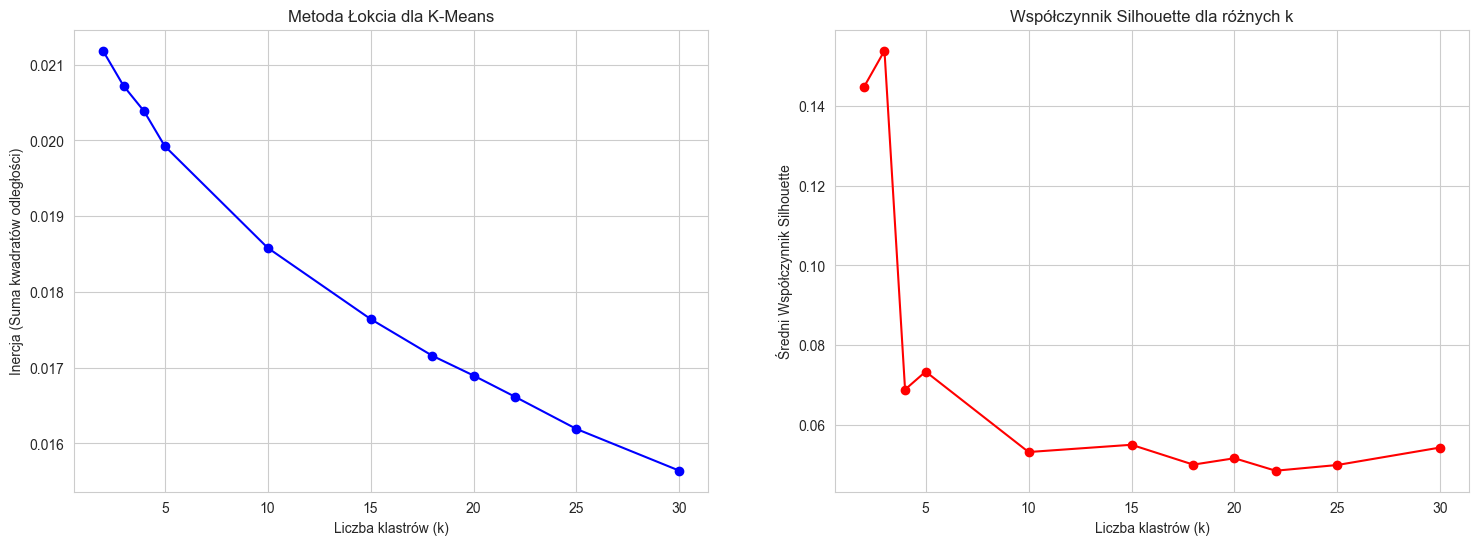

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

ax1.plot(k_values_to_test, inertia_values, 'bo-')
ax1.set_xlabel('Liczba klastrów (k)')
ax1.set_ylabel('Inercja (Suma kwadratów odległości)')
ax1.set_title('Metoda Łokcia dla K-Means')
ax1.grid(True)

ax2.plot(k_values_to_test, silhouette_values, 'ro-')
ax2.set_xlabel('Liczba klastrów (k)')
ax2.set_ylabel('Średni Współczynnik Silhouette')
ax2.set_title('Współczynnik Silhouette dla różnych k')
ax2.grid(True)

plt.show()

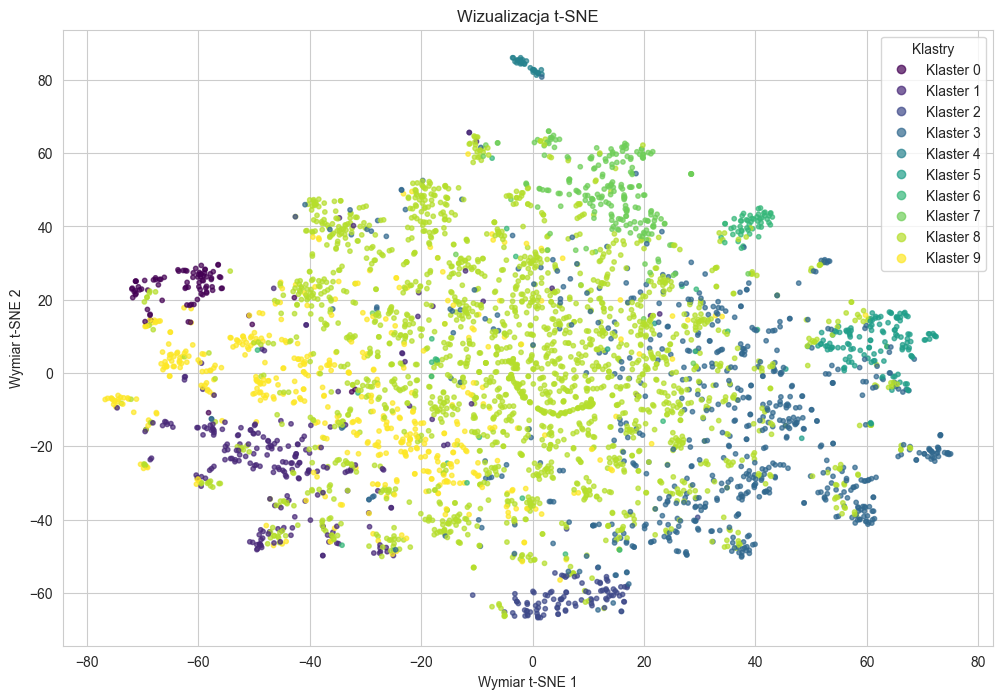

In [14]:
# t-SNE

chosen_k = 10
final_kmeans = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
final_kmeans.fit(pca_matrix)
cluster_labels = final_kmeans.labels_

n_samples_for_tsne = 4000
np.random.seed(42)
sample_indices = np.random.choice(pca_matrix.shape[0], n_samples_for_tsne, replace=False)

pca_matrix_sample = pca_matrix[sample_indices]
labels_sample = cluster_labels[sample_indices]

tsne = TSNE(n_components=2, random_state=42, perplexity=15, init='pca')
matrix_2d = tsne.fit_transform(pca_matrix_sample)
plt.figure(figsize=(12, 8))
scatter = plt.scatter(matrix_2d[:, 0], matrix_2d[:, 1], c=labels_sample, cmap='viridis', s=10, alpha=0.7)

plt.title(f'Wizualizacja t-SNE')
plt.xlabel('Wymiar t-SNE 1')
plt.ylabel('Wymiar t-SNE 2')


legend_labels = [f'Klaster {i}' for i in range(k)]
plt.legend(handles=scatter.legend_elements()[0], labels=legend_labels, title="Klastry")

plt.grid(True)
plt.show()

In [15]:
df_analysis = pd.DataFrame({
    'cluster_id': cluster_labels,
    'original_text': newsgroups_train.data
})

samples_per_cluster = 3

for k in range(chosen_k):


    cluster_size = (df_analysis['cluster_id'] == k).sum()
    print(f"\n\n--- KLASTER {k} (Łącznie {cluster_size} tekstów) ---")


    n_samples = min(samples_per_cluster, cluster_size)
    if n_samples == 0:
        print("Brak tekstów w tym klastrze.")
        continue

    sample_texts = df_analysis[df_analysis['cluster_id'] == k].sample(
        n_samples,
    )['original_text']

    for i, text in enumerate(sample_texts):
        print(f"\n[Przykład {i+1} / Klaster {k}]")
        cleaned_text = " ".join(text.split())
        print(cleaned_text[:1000] + "...")




--- KLASTER 0 (Łącznie 257 tekstów) ---

[Przykład 1 / Klaster 0]
The docs say that it's a SCSI Manager bug, if this changes things at all......

[Przykład 2 / Klaster 0]
Do you need to get a ROM upgrade to use a 1.4 Mb floppy drive with a Mac II? Or are there 3rd party drives which work with the Mac II's own ROMs? Thanks, Ralph -- Ralph Gonzalez, Computer Science, Rutgers Univ., Camden, NJ Phone: (609) 225-6122; Internet: rgonzal@gandalf.rutgers.edu...

[Przykład 3 / Klaster 0]
I have a 486DX 25mhz with local bus. Would I see much of an increase in speed in my drives if I got a VESA IDE controller card? I need advice!...


--- KLASTER 1 (Łącznie 643 tekstów) ---

[Przykład 1 / Klaster 1]
Hi everyone, I thought that some people may be interested in my VR software on these groups: *******Announcing the release of Multiverse-1.0.2******* Multiverse is a multi-user, non-immersive, X-Windows based Virtual Reality system, primarily focused on entertainment/research. Features: Client-Serve

In [ ]:
# zadanie 5

class CustomKMeans:
    def __init__(self, k, max_iters = 100):
        self.k = k
        self.max_iters = max_iters
        self.centroids = None # potem np array, shape = (k, n_cech)
        self.history = {'centroids' : [], 'labels' : []} # do wizualizacji

    def _init_centroids(self, X):
        # inicjalizujemy k unikalnych centroidow
        # np.random.seed(42)
        random_idc = np.random.choice(X.shape[0], self.k, replace=False)
        self.centroids = X[random_idc]

    def _assign_clusters(self, X):
        # obliczamy odleglosc (euklidesowa) od kazdego punktu do kazdego centroidu
        # X.shape() := (n_samples, n_feat)
        # self.centoids shape() := (n_clusters, n_feat)
        X_sq = np.sum(X**2, axis=1).reshape(-1, 1)
        C_sq = np.sum(self.centroids**2, axis=1).reshape(1, -1)
        XC = X @ self.centroids.T

        distances = X_sq - 2*XC + C_sq

        labels = np.argmin(distances, axis=1)
        return labels

    def _update_centroids(self, X, labels):
        new_centroids = np.zeros((self.k, X.shape[1]))
        for k in range(self.k):
            cluster_points = X[labels == k]

            if len(cluster_points) > 0:
                new_centroids[k] = np.mean(cluster_points, axis=0)
            else:
                new_centroids[k] = X[np.random.choice(X.shape[0])]

        self.centroids = new_centroids

    def fit(self, X):
        self._init_centroids(X)

        for i in range(self.max_iters):
            labels = self._assign_clusters(X)

            self.history['centroids'].append(np.copy(self.centroids))
            self.history['labels'].append(labels)

            old_centroids = np.copy(self.centroids)
            self._update_centroids(X, labels)
            if np.all(old_centroids == self.centroids):
                break

    def predict(self, X):
        return self._assign_clusters(X)

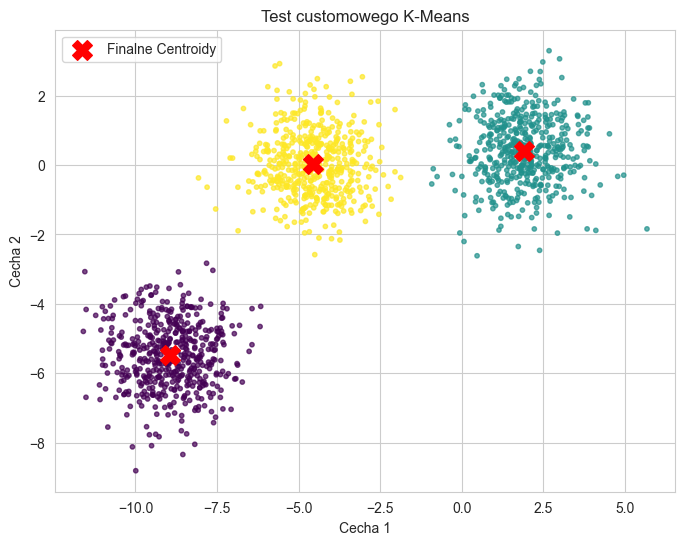

In [17]:
# test
test_data = np.load('data1.npy')

k_test = 3
my_model = CustomKMeans(k=k_test)

my_model.fit(test_data)
labels = my_model.predict(test_data)

plt.figure(figsize=(8, 6))
plt.scatter(test_data[:, 0], test_data[:, 1], c=labels, cmap='viridis', s=10, alpha=0.7)
plt.scatter(my_model.centroids[:, 0], my_model.centroids[:, 1], c='red', marker='X', s=200, label='Finalne Centroidy')
plt.title('Test customowego K-Means')
plt.xlabel('Cecha 1')
plt.ylabel('Cecha 2')
plt.legend()
plt.grid(True)
plt.show()